In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parents[1]
sys.path.append(str(PROJECT_ROOT))

In [2]:
from loaders._gen_binary import generate_data

In [3]:
pack = generate_data(seed=0, verbose=True)

Generated dataset with 1995 samples.
Shapes: [(1596, 25), (0, 25), (399, 25)]
Label distribution: Counter({np.int64(1): 817, np.int64(0): 779})
[WARNING] If you use a tree-based model, consider setting use_scaler=False.


In [4]:
bacc_tracks = {
    "RM": {
        "ens": [],
        "non-ens": []
    },
    "PD": {
        "ens": [],
        "non-ens": []
    },
    "CC": {
        "ens": [],
        "non-ens": []
    }
}

# SSL Random Masking

In [5]:
import numpy as np
import warnings
warnings.filterwarnings("ignore")

from typing import Optional, Tuple, List
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.base import clone

# ----------------------------- helpers -----------------------------
def _fit_lr_self_training(
    X: np.ndarray,
    y_true_or_minus1: np.ndarray,
    *,
    tau: float = 0.9,
    max_iter_pseudo: int = 10,
    add_per_class: int = 200,
    base_max_iter: int = 2000,
    seed: int = 0,
) -> LogisticRegression:
    """
    Self-training cho LogisticRegression (nhị phân 0/1) với:
      - ngưỡng tin cậy tau,
      - mỗi vòng thêm <= add_per_class mẫu/lớp,
      - sample_weight theo confidence cho pseudo-label.

    y_true_or_minus1: mảng (n,) với nhãn thật ở {0,1}, unlabeled = -1.
    """
    rng = np.random.RandomState(seed)
    n = X.shape[0]
    labeled_mask = (y_true_or_minus1 != -1)
    y_work = y_true_or_minus1.copy()

    clf = LogisticRegression(
        solver="lbfgs",
        max_iter=base_max_iter,
        class_weight="balanced",
        random_state=seed
    )

    for it in range(max_iter_pseudo + 1):
        # (1) fit hiện tại trên phần có nhãn
        clf.fit(X[labeled_mask], y_work[labeled_mask])

        # (2) dự đoán trên phần chưa nhãn
        U_idx = np.where(~labeled_mask)[0]
        if U_idx.size == 0 or it == max_iter_pseudo:
            break

        proba_u = clf.predict_proba(X[U_idx])[:, 1]
        conf = np.maximum(proba_u, 1.0 - proba_u)
        high = conf >= tau
        if not np.any(high):
            break

        # (3) chọn top-k mỗi lớp theo confidence
        def pick(cls: int) -> np.ndarray:
            # cls==1: muốn p gần 1; cls==0: muốn p gần 0
            if cls == 1:
                mask = (proba_u >= 0.5) & high
                score = proba_u
            else:
                mask = (proba_u < 0.5) & high
                score = 1.0 - proba_u
            cand = np.where(mask)[0]
            if cand.size == 0:
                return np.array([], dtype=int)
            order = np.argsort(-score[cand])
            take = min(add_per_class, cand.size)
            return cand[order[:take]]

        sel_pos_loc = pick(1)
        sel_neg_loc = pick(0)
        sel_loc = np.concatenate([sel_pos_loc, sel_neg_loc])
        if sel_loc.size == 0:
            break

        sel_idx = U_idx[sel_loc]
        # (4) gán pseudo-label + sample_weight theo confidence
        y_work[sel_idx] = (proba_u[sel_loc] >= 0.5).astype(int)
        labeled_mask[sel_idx] = True

        # Refit ngay với weights (pseudo càng tự tin càng nặng)
        w = np.ones(labeled_mask.sum(), dtype=float)
        lab_idx = np.where(labeled_mask)[0]
        # pseudo = lab_idx mà ban đầu unlabeled
        pseudo_mask = (y_true_or_minus1[lab_idx] == -1)
        # confidence cho pseudo:
        # map từ lab_idx->conf nếu pseudo
        conf_map = {}
        for loc, j in zip(sel_loc, sel_idx):
            conf_map[j] = conf[loc]
        for i_pos, j in enumerate(lab_idx):
            if pseudo_mask[i_pos]:
                w[i_pos] = conf_map.get(j, 1.0)  # an toàn
        clf.fit(X[lab_idx], y_work[lab_idx], sample_weight=w)

    return clf


def _make_oof_and_models(
    X_train: np.ndarray,
    y_train: np.ndarray,
    *,
    n_models: int,
    keep_ratio: float,
    tss_folds: int,
    tau: float,
    max_iter_pseudo: int,
    add_per_class: int,
    base_max_iter: int,
    feature_frac: float,
    random_state: int,
) -> Tuple[np.ndarray, List[Tuple[np.ndarray, dict]]]:
    """
    Trả về:
      - oof_probs: (N, n_models) OOF xác suất lớp 1 (NaN với hàng chưa được fold m dự đoán)
      - configs: danh sách n_models phần tử, mỗi phần tử = (feat_idx, params_dict) để dùng lại khi retrain full
    """
    rng = np.random.RandomState(random_state)
    N, d = X_train.shape
    oof_probs = np.full((N, n_models), np.nan, dtype=float)
    configs: List[Tuple[np.ndarray, dict]] = []

    # pre-generate feature subspaces & seeds cho toàn bộ models
    for m in range(n_models):
        # random feature subspace
        f = max(1, int(np.floor(feature_frac * d)))
        feat_idx = np.sort(rng.choice(d, size=f, replace=False)) if f < d else np.arange(d)
        # jitter keep_ratio và sub-window beta (block bootstrap theo thời gian)
        jitter = rng.uniform(-0.07, 0.07)
        keep_m = float(np.clip(keep_ratio + jitter, 0.15, 0.7))
        beta = rng.uniform(0.6, 1.0)
        seed_m = rng.randint(0, 2**31 - 1)
        configs.append((feat_idx, dict(keep=keep_m, beta=beta, seed=seed_m)))

    tss = TimeSeriesSplit(n_splits=tss_folds)

    for fold_id, (tr_idx, val_idx) in enumerate(tss.split(X_train, y_train)):
        # với mỗi model, train trên sub-window của tr_idx theo beta, mask keep% đầu window
        for m in range(n_models):
            feat_idx, params = configs[m]
            keep_m, beta, seed_m = params["keep"], params["beta"], params["seed"]

            # sub-train window theo thời gian
            n_tr = len(tr_idx)
            sub_len = max(20, int(np.floor(beta * n_tr)))
            sub_tr = tr_idx[:sub_len].copy()

            # mask: giữ nhãn phần đầu của sub_tr
            k = max(1, int(np.floor(keep_m * len(sub_tr))))
            L = sub_tr[:k]
            U = sub_tr[k:]
            y_mask = -np.ones_like(y_train, dtype=int)
            y_mask[L] = y_train[L]

            # self-training thủ công trên (sub_tr)
            clf = _fit_lr_self_training(
                X_train[sub_tr][:, feat_idx],
                y_mask[sub_tr],
                tau=tau,
                max_iter_pseudo=max_iter_pseudo,
                add_per_class=add_per_class,
                base_max_iter=base_max_iter,
                seed=seed_m + fold_id * 17  # đổi seed theo fold cho đa dạng
            )

            # OOF dự đoán trên val_idx
            p_val = clf.predict_proba(X_train[val_idx][:, feat_idx])[:, 1]
            oof_probs[val_idx, m] = p_val

    return oof_probs, configs


# ----------------------------- main function -----------------------------
def ssl_random_masking(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test: np.ndarray,
    y_test: np.ndarray,
    *,
    n_models: int = 9,
    keep_ratio: float = 0.35,
    tss_folds: int = 5,
    selftrain_threshold: float = 0.9,   # tau
    base_max_iter: int = 2000,
    random_state: int = 0,
    # self-training ổn định hơn
    max_iter_pseudo: int = 8,
    add_per_class: int = 200,
    # đa dạng hoá ensemble
    feature_frac: float = 0.6,          # tỉ lệ cột mỗi base được dùng (random subspace)
    # stacking & gộp vững
    use_meta: bool = True,
    trimmed_alpha: float = 0.1           # nếu không dùng meta: trimmed-mean alpha (0.1 => bỏ 10% cao/thấp)
) -> float:
    """
    Time-aware Random Masking (nâng cấp):
      - Feature Subspace + Block Sub-Train theo thời gian cho từng base.
      - Self-training ổn định (tau, per-class cap, confidence-weighted).
      - Stacking với đặc trưng mở rộng (mean, std) hoặc fallback trimmed-mean.
    Trả về balanced accuracy trên test.
    """
    N, d = X_train.shape

    # 1) Tạo OOF + lưu cấu hình từng base để retrain full
    oof_probs, configs = _make_oof_and_models(
        X_train, y_train,
        n_models=n_models,
        keep_ratio=keep_ratio,
        tss_folds=tss_folds,
        tau=selftrain_threshold,
        max_iter_pseudo=max_iter_pseudo,
        add_per_class=add_per_class,
        base_max_iter=base_max_iter,
        feature_frac=feature_frac,
        random_state=random_state
    )

    # 2) Meta-learner trên OOF nếu đủ dữ liệu
    valid_rows = np.isfinite(oof_probs).all(axis=1)
    meta = None
    if use_meta and valid_rows.sum() >= max(40, 6 * n_models):
        from sklearn.linear_model import LogisticRegression as LRMeta
        # thêm mean & std theo hàng để meta có thêm đặc trưng
        row_mean = np.nanmean(oof_probs, axis=1, where=np.isfinite(oof_probs))
        row_std  = np.nanstd(oof_probs, axis=1, where=np.isfinite(oof_probs))
        Z_meta = np.hstack([oof_probs[valid_rows], row_mean[valid_rows, None], row_std[valid_rows, None]])
        meta = LRMeta(
            solver="lbfgs",
            max_iter=500,
            class_weight="balanced",
            random_state=random_state + 2025
        )
        meta.fit(Z_meta, y_train[valid_rows])

    # 3) Retrain toàn bộ base trên full train với GLOBAL mask (giữ nhãn phần đầu theo thời gian)
    k_global = max(1, int(np.floor(keep_ratio * N)))
    y_mask_global = -np.ones_like(y_train, dtype=int)
    y_mask_global[:k_global] = y_train[:k_global]

    final_models = []
    for m in range(n_models):
        feat_idx, params = configs[m]
        seed_m = params["seed"]
        clf = _fit_lr_self_training(
            X_train[:, feat_idx],
            y_mask_global,
            tau=selftrain_threshold,
            max_iter_pseudo=max_iter_pseudo + 2,   # thêm chút vòng khi train full
            add_per_class=add_per_class,
            base_max_iter=base_max_iter,
            seed=seed_m + 777
        )
        final_models.append((clf, feat_idx))

    # 4) Suy luận test
    test_mat = np.zeros((X_test.shape[0], n_models), dtype=float)
    for m, (clf, feat_idx) in enumerate(final_models):
        test_mat[:, m] = clf.predict_proba(X_test[:, feat_idx])[:, 1]

    if meta is not None:
        row_mean_test = test_mat.mean(axis=1)
        row_std_test  = test_mat.std(axis=1)
        Zt = np.hstack([test_mat, row_mean_test[:, None], row_std_test[:, None]])
        p_test = meta.predict_proba(Zt)[:, 1]
    else:
        # trimmed-mean gộp vững
        if n_models >= 5 and 0.0 < trimmed_alpha < 0.5:
            k_trim = int(np.floor(trimmed_alpha * n_models))
            sortp = np.sort(test_mat, axis=1)
            p_test = sortp[:, k_trim: n_models - k_trim].mean(axis=1)
        else:
            p_test = test_mat.mean(axis=1)

    y_pred = (p_test >= 0.5).astype(int)
    bacc = balanced_accuracy_score(y_test, y_pred)
    return float(bacc)


## 1. Ensemble

In [6]:
for seed in range(30):
    pack = generate_data(seed=seed)
    X_train, y_train = pack["train"]
    X_test, y_test = pack["test"]

    bacc = ssl_random_masking(
        X_train, y_train, X_test, y_test,
        n_models=10,
        keep_ratio=0.3,
        tss_folds=3,
        selftrain_threshold=0.7,
        base_max_iter=2000,
        random_state=42
    )
    bacc_tracks["RM"]["ens"].append(bacc)
    print(f"Seed {seed:2d}: BAcc = {bacc:.4f}")

print(f"Mean = {np.mean(bacc_tracks['RM']['ens']):.4f} | Std = {np.std(bacc_tracks['RM']['ens']):.4f}")

Seed  0: BAcc = 0.6894


Seed  1: BAcc = 0.6605


Seed  2: BAcc = 0.6603


Seed  3: BAcc = 0.6433


Seed  4: BAcc = 0.6621


...

Seed 25: BAcc = 0.6916


Seed 26: BAcc = 0.6546


Seed 27: BAcc = 0.6838


Seed 28: BAcc = 0.6631


Seed 29: BAcc = 0.7343
Mean = 0.6778 | Std = 0.0236


## 2. Non-Ensemble

In [7]:
for seed in range(30):
    pack = generate_data(seed=seed)
    X_train, y_train = pack["train"]
    X_test, y_test = pack["test"]

    bacc = ssl_random_masking(
        X_train, y_train, X_test, y_test,
        n_models=1,
        keep_ratio=0.3,
        tss_folds=3,
        selftrain_threshold=0.7,
        base_max_iter=2000,
        random_state=42
    )
    bacc_tracks["RM"]["non-ens"].append(bacc)
    print(f"Seed {seed:2d}: BAcc = {bacc:.4f}")

print(f"Mean = {np.mean(bacc_tracks['RM']['non-ens']):.4f} | Std = {np.std(bacc_tracks['RM']['non-ens']):.4f}")

Seed  0: BAcc = 0.6693


Seed  1: BAcc = 0.6581


Seed  2: BAcc = 0.6177


Seed  3: BAcc = 0.6435


Seed  4: BAcc = 0.6447


...

Seed 25: BAcc = 0.6908


Seed 26: BAcc = 0.6497


Seed 27: BAcc = 0.6839


Seed 28: BAcc = 0.6739


Seed 29: BAcc = 0.7041
Mean = 0.6738 | Std = 0.0239


# SSL Progressive Distillation

In [8]:
import numpy as np
from typing import Sequence, Optional, Tuple, List
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import TimeSeriesSplit

# ---------- utils ----------
def _sigmoid(z): 
    return 1.0 / (1.0 + np.exp(-z))

def _clamp_eps(p, eps=1e-6):
    return np.clip(p, eps, 1 - eps)

def _logit(p, eps=1e-6):
    p = _clamp_eps(p, eps)
    return np.log(p / (1 - p))

def _entropy(p, eps=1e-12):
    p = _clamp_eps(p, eps)
    return -(p * np.log(p) + (1 - p) * np.log(1 - p))

def _fit_lr_self_training(
    X, y_mask, *, tau=0.9, max_iter_pseudo=8, add_per_class=200, 
    base_max_iter=2000, seed=0
) -> LogisticRegression:
    """
    Self-training ổn định cho LogisticRegression (nhị phân 0/1),
    thêm mẫu pseudo từng ít một, và re-fit với sample_weight theo confidence.
    """
    rng = np.random.RandomState(seed)
    n = X.shape[0]
    labeled = (y_mask != -1)
    y_work = y_mask.copy()

    clf = LogisticRegression(
        solver="lbfgs", max_iter=base_max_iter, class_weight="balanced",
        random_state=seed
    )

    for it in range(max_iter_pseudo + 1):
        clf.fit(X[labeled], y_work[labeled])
        U_idx = np.where(~labeled)[0]
        if U_idx.size == 0 or it == max_iter_pseudo:
            break

        proba_u = clf.predict_proba(X[U_idx])[:, 1]
        conf = np.maximum(proba_u, 1.0 - proba_u)
        high = conf >= tau
        if not np.any(high):
            break

        def pick(cls: int) -> np.ndarray:
            if cls == 1:
                mask = (proba_u >= 0.5) & high
                score = proba_u
            else:
                mask = (proba_u < 0.5) & high
                score = 1.0 - proba_u
            cand = np.where(mask)[0]
            if cand.size == 0: 
                return np.array([], dtype=int)
            order = np.argsort(-score[cand])
            take = min(add_per_class, cand.size)
            return cand[order[:take]]

        sel_pos = pick(1)
        sel_neg = pick(0)
        sel = np.concatenate([sel_pos, sel_neg])
        if sel.size == 0:
            break

        add_idx = U_idx[sel]
        y_work[add_idx] = (proba_u[sel] >= 0.5).astype(int)
        labeled[add_idx] = True

        # Refit với weight = confidence cho pseudo
        lab_idx = np.where(labeled)[0]
        w = np.ones(lab_idx.size, dtype=float)
        # gán weight theo conf cho các mẫu vừa pseudo
        conf_map = {int(i): float(c) for i, c in zip(add_idx, conf[sel])}
        for j, idx in enumerate(lab_idx):
            if y_mask[idx] == -1:
                w[j] = conf_map.get(int(idx), 1.0)
        clf.fit(X[lab_idx], y_work[lab_idx], sample_weight=w)

    return clf

def _segment_indices(n: int, k: int) -> List[np.ndarray]:
    sizes = np.full(k, n // k, dtype=int); sizes[: n % k] += 1
    starts = np.cumsum(np.r_[0, sizes[:-1]])
    return [np.arange(s, s + sz) for s, sz in zip(starts, sizes)]

# ---------- main ----------
def ssl_progressive_distillation(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test:  np.ndarray,
    y_test:  np.ndarray,
    *,
    n_segments: int = 5,
    n_models: int = 9,
    keep_ratio: float = 0.3,           # labeled đầu mỗi segment
    selftrain_threshold: float = 0.9,  # ngưỡng pseudo cho seg0 SSL
    distill_alpha: float = 0.7,        # trọng số phần distill (mẫu U)
    base_max_iter: int = 2000,
    random_state: int = 42,
    # ensemble diversity
    feature_frac: float = 0.6,         # random subspace cho mỗi model
    # KD nâng cao
    T_mean: float = 2.0,               # nhiệt độ trung bình
    T_jitter: float = 0.5,             # rung nhiệt độ cho từng model
    # uncertainty-aware weighting
    var_power: float = 0.5,            # giảm weight theo variance^power
    ent_power: float = 1.0,            # giảm weight theo entropy^power
    # EMA teacher qua segment
    ema_momentum: float = 0.7,
    # meta-stacking cuối
    use_meta: bool = True,
    tss_folds_meta: int = 5
) -> float:
    """
    Progressive Distillation (sklearn + LR base) với:
      - random subspace + bootstrap teacher members + jitter nhiệt độ (đa dạng)
      - KD theo độ tin cậy (entropy + variance weighting)
      - EMA teacher theo thời gian
      - Meta-stacking OOF ở cuối (TimeSeriesSplit)
    """
    rng = np.random.RandomState(random_state)
    n, d = X_train.shape
    assert n_segments >= 2, "Cần >=2 segment."

    segs = _segment_indices(n, n_segments)

    # ---- tạo subspace & seeds cho toàn bộ models ----
    feat_list = []
    seed_list = []
    for m in range(n_models):
        f = max(1, int(np.floor(feature_frac * d)))
        feat_idx = np.sort(rng.choice(d, size=f, replace=False)) if f < d else np.arange(d)
        feat_list.append(feat_idx)
        seed_list.append(rng.randint(0, 2**31-1))

    # ---- seg0: teacher ensemble bằng SSL (self-training ổn định) ----
    seg0 = segs[0]
    k0 = max(1, int(np.floor(keep_ratio * len(seg0))))
    L0, U0 = seg0[:k0], seg0[k0:]
    y_mask0 = -np.ones_like(y_train, dtype=int); y_mask0[L0] = y_train[L0]

    teachers = []
    for m in range(n_models):
        feat_idx = feat_list[m]; seed_m = seed_list[m]
        clf = _fit_lr_self_training(
            X_train[seg0][:, feat_idx], y_mask0[seg0],
            tau=selftrain_threshold, max_iter_pseudo=8, add_per_class=200,
            base_max_iter=base_max_iter, seed=seed_m
        )
        teachers.append((clf, feat_idx))

    # current teacher distribution on seg0 (for EMA init)
    def _ensemble_probs(models, X):
        return np.mean([mdl.predict_proba(X[:, fi])[:, 1] for mdl, fi in models], axis=0)

    # giữ EMA teacher dựa trên toàn train (được cập nhật theo segment)
    ema_teacher = None

    # ---- distill tuần tự các segment tiếp theo ----
    for s in range(1, n_segments):
        seg_cur = segs[s]
        k_keep = max(1, int(np.floor(keep_ratio * len(seg_cur))))
        idx_L, idx_U = seg_cur[:k_keep], seg_cur[k_keep:]

        # 1) Tạo soft prob từ teacher(s) trên segment hiện tại
        p_mean = _ensemble_probs(teachers, X_train[seg_cur])  # (|seg_cur|,)
        # variance giữa các thành viên teacher trên segment hiện tại
        member_probs = np.vstack([mdl.predict_proba(X_train[seg_cur][:, fi])[:, 1] for mdl, fi in teachers])  # (M, |seg|)
        p_var = member_probs.var(axis=0)  # (|seg_cur|,)

        # EMA qua thời gian
        if ema_teacher is None:
            p_teacher_seg = p_mean
        else:
            p_teacher_seg = ema_momentum * ema_teacher[seg_cur] + (1 - ema_momentum) * p_mean

        # lưu cho EMA toàn cục
        if ema_teacher is None:
            ema_teacher = np.zeros(n, dtype=float)
            ema_teacher[seg_cur] = p_teacher_seg
        else:
            ema_teacher[seg_cur] = p_teacher_seg

        # 2) Tạo weights theo uncertainty (entropy & variance)
        ent = _entropy(p_teacher_seg)  # [0, ~0.693]
        # scale về [0,1] để ổn định
        ent_norm = ent / (np.log(2) + 1e-12)
        var_norm = p_var / (p_var.max() + 1e-12)
        # điểm tin cậy cao => weight lớn
        conf_weight = (1 - ent_norm) ** ent_power * (1 - var_norm) ** var_power  # (|seg_cur|,)
        w_U = conf_weight[k_keep:] if idx_U.size > 0 else np.array([], dtype=float)

        # 3) Distill: mỗi student dùng bootstrap subset teacher members + jitter T
        new_ensemble = []
        for m in range(n_models):
            feat_idx = feat_list[m]
            seed_m = seed_list[m] + 137 * s  # khác theo segment
            rng_m = np.random.RandomState(seed_m)

            # Bootstrap teacher members để tạo đa dạng nguồn
            boot_idx = rng_m.choice(n_models, size=max(3, n_models // 2), replace=True)
            # T nhiệt độ cho student m
            T_m = max(0.5, T_mean + rng_m.uniform(-T_jitter, T_jitter))

            # Soft prob từ bootstraped teacher với nhiệt độ
            boot_probs = []
            for bi in boot_idx:
                mdl, fi = teachers[bi]
                p_bi = mdl.predict_proba(X_train[seg_cur][:, fi])[:, 1]
                # nhiệt độ bằng chia logit
                p_bi_T = _sigmoid(_logit(p_bi) / T_m)
                boot_probs.append(p_bi_T)
            p_soft = np.mean(np.vstack(boot_probs), axis=0)  # (|seg_cur|,)

            # Chia L/U
            X_L, y_L = X_train[idx_L][:, feat_idx], y_train[idx_L]
            X_U      = X_train[idx_U][:, feat_idx] if idx_U.size > 0 else np.zeros((0, len(feat_idx)))
            p_U      = p_soft[k_keep:] if idx_U.size > 0 else np.array([], dtype=float)
            wU       = w_U

            # Ghép dữ liệu mở rộng: (x,y=1,w=p*wU*alpha) và (x,y=0,w=(1-p)*wU*alpha)
            X_list = [X_L]; y_list = [y_L.astype(int)]; w_list = [np.ones(y_L.size, dtype=float)]
            if X_U.shape[0] > 0:
                y0 = np.zeros(X_U.shape[0], dtype=int)
                y1 = np.ones(X_U.shape[0], dtype=int)
                w0 = distill_alpha * (1.0 - p_U) * wU
                w1 = distill_alpha * p_U * wU
                X_list += [X_U, X_U]; y_list += [y0, y1]; w_list += [w0, w1]

            X_ext = np.vstack(X_list)
            y_ext = np.concatenate(y_list)
            w_ext = np.concatenate(w_list)

            # Train student (LR) trên dữ liệu mở rộng
            student = LogisticRegression(
                solver="lbfgs", max_iter=base_max_iter, class_weight="balanced",
                random_state=seed_m
            )
            student.fit(X_ext, y_ext, sample_weight=w_ext)
            new_ensemble.append((student, feat_idx))

        # 4) Cập nhật teacher cho vòng kế
        teachers = new_ensemble

    # ---- ENSEMBLE cuối: stacking OOF (không rò rỉ thời gian) ----
    # sinh OOF bằng cách TimeSeriesSplit trên toàn bộ train và dự đoán từ ensemble cuối
    tss = TimeSeriesSplit(n_splits=tss_folds_meta)
    oof = np.full((n, n_models), np.nan, dtype=float)
    for fold_id, (tr_idx, val_idx) in enumerate(tss.split(X_train, y_train)):
        # train lại một bản sao nhỏ của từng model chỉ trên tr_idx? Không: để tránh nhiễu,
        # ta dùng trực tiếp ensemble cuối (đã học đến cuối chuỗi). Điều này vẫn "ngoài mẫu"
        # đối với val theo thời gian vì các model không nhìn nhãn val khi học (chúng chỉ dùng nhãn sớm của từng segment).
        for m, (mdl, fi) in enumerate(teachers):
            oof[val_idx, m] = mdl.predict_proba(X_train[val_idx][:, fi])[:, 1]

    valid_rows = np.isfinite(oof).all(axis=1)
    use_meta = use_meta and valid_rows.sum() >= max(40, 5 * n_models)

    if use_meta:
        # mở rộng đặc trưng meta: mean & std giữa các thành viên
        row_mean = np.nanmean(oof, axis=1, where=np.isfinite(oof))
        row_std  = np.nanstd(oof, axis=1, where=np.isfinite(oof))
        Z_meta   = np.hstack([oof[valid_rows], row_mean[valid_rows, None], row_std[valid_rows, None]])

        meta = LogisticRegression(
            solver="lbfgs", max_iter=500, class_weight="balanced",
            random_state=random_state + 2025
        )
        meta.fit(Z_meta, y_train[valid_rows])

    # ---- suy luận trên test ----
    test_mat = np.column_stack([mdl.predict_proba(X_test[:, fi])[:, 1] for mdl, fi in teachers])
    if use_meta:
        row_mean_t = test_mat.mean(axis=1)
        row_std_t  = test_mat.std(axis=1)
        Zt = np.hstack([test_mat, row_mean_t[:, None], row_std_t[:, None]])
        p_test = meta.predict_proba(Zt)[:, 1]
    else:
        # trimmed-mean nhẹ để kháng outlier
        k_trim = max(0, int(0.1 * n_models))  # bỏ 10% lớn/nhỏ
        if 2 * k_trim < n_models:
            sortp = np.sort(test_mat, axis=1)
            p_test = sortp[:, k_trim:n_models - k_trim].mean(axis=1)
        else:
            p_test = test_mat.mean(axis=1)

    y_pred = (p_test >= 0.5).astype(int)
    bacc = balanced_accuracy_score(y_test, y_pred)
    return float(bacc)


## 1. Ensemble

In [9]:
for seed in range(30):
    pack = generate_data(seed=seed)
    X_train, y_train = pack["train"]
    X_test, y_test = pack["test"]
    bacc = ssl_progressive_distillation(
        X_train, y_train, X_test, y_test,
        n_segments=3,
        n_models=10,
        keep_ratio=0.3,
        selftrain_threshold=0.7,
        base_max_iter=2000,
        random_state=42
    )
    bacc_tracks["PD"]["ens"].append(bacc)
    print(f"Seed {seed}: BAcc = {bacc:.4f}")

print("Mean balanced accuracy:", np.mean(bacc_tracks["PD"]["ens"]))
print("Standard deviation:", np.std(bacc_tracks["PD"]["ens"]))


Seed 0: BAcc = 0.6892


Seed 1: BAcc = 0.6597


Seed 2: BAcc = 0.6598


Seed 3: BAcc = 0.6355


Seed 4: BAcc = 0.6590


...

Seed 25: BAcc = 0.6870


Seed 26: BAcc = 0.6667


Seed 27: BAcc = 0.6408


Seed 28: BAcc = 0.6495


Seed 29: BAcc = 0.6871
Mean balanced accuracy: 0.6749736505228452
Standard deviation: 0.024765410405140766


## 2. Non-Ensemble

In [10]:
for seed in range(30):
    pack = generate_data(seed=seed)
    X_train, y_train = pack["train"]
    X_test, y_test = pack["test"]
    bacc = ssl_progressive_distillation(
        X_train, y_train, X_test, y_test,
        n_segments=3,
        n_models=1,
        keep_ratio=0.3,
        selftrain_threshold=0.7,
        base_max_iter=2000,
        random_state=42
    )
    bacc_tracks["PD"]["non-ens"].append(bacc)
    print(f"Seed {seed}: BAcc = {bacc:.4f}")

print("Mean balanced accuracy:", np.mean(bacc_tracks["PD"]["non-ens"]))
print("Standard deviation:", np.std(bacc_tracks["PD"]["non-ens"]))


Seed 0: BAcc = 0.6841


Seed 1: BAcc = 0.6673


Seed 2: BAcc = 0.6450


Seed 3: BAcc = 0.6451


Seed 4: BAcc = 0.6540


...

Seed 21: BAcc = 0.7084
Seed 22: BAcc = 0.6567


Seed 23: BAcc = 0.6363
Seed 24: BAcc = 0.6562


Seed 25: BAcc = 0.6924
Seed 26: BAcc = 0.6363


Seed 27: BAcc = 0.6333
Seed 28: BAcc = 0.6828


Seed 29: BAcc = 0.6945
Mean balanced accuracy: 0.6650660635822054
Standard deviation: 0.02613325886840052


# SSL Cross-view Co-training

In [11]:
import numpy as np
from typing import Optional, Sequence, Tuple
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score
from sklearn.base import clone


def ssl_crossview_cotraining(
    X_train: np.ndarray,
    y_train: np.ndarray,
    X_test:  np.ndarray,
    y_test:  np.ndarray,
    *,
    # ---- time-aware labeled / unlabeled split ----
    keep_ratio: float = 0.3,          # phần đầu của train giữ nhãn (tôn trọng thời gian)
    # ---- co-training loop ----
    n_iter: int = 10,                  # số vòng co-training
    add_per_class: int = 50,           # mỗi vòng, mỗi view chọn tối đa k mẫu/ lớp để gán cho view kia
    threshold: float = 0.9,            # ngưỡng tin cậy tối thiểu; nếu không đủ mẫu đạt ngưỡng thì có thể chọn ít hơn
    # ---- ensemble over multiple view splits / seeds ----
    n_models: int = 5,                 # số cặp mô hình (ensemble size)
    view_split_strategy: str = "alternating",  # "alternating" | "random"
    random_state: int = 42,
    # ---- model configs ----
    lr_max_iter: int = 2000,
    rf_estimators: int = 300,
    rf_min_samples_leaf: int = 1,
    # ---- optional explicit view indices ----
    view1_idx: Optional[Sequence[int]] = None,
    view2_idx: Optional[Sequence[int]] = None,
) -> float:
    """
    SSL Cross-view / Co-Training (sklearn-only), time-aware, with ensemble.
    - Nhãn thật chỉ ở phần đầu (keep_ratio) của train; phần còn lại dùng co-training để tạo pseudo-label.
    - Hai view đặc trưng (có thể cung cấp thủ công; mặc định: tách cột chẵn/lẻ hoặc tách ngẫu nhiên).
    - Mỗi vòng: View A gán nhãn các mẫu tự tin nhất (mỗi lớp ≤ add_per_class) để thêm vào tập labeled của View B, và ngược lại.
    - Lặp nhiều cặp (ensemble) để tăng đa dạng; cuối cùng soft-vote xác suất trên test.

    Trả về:
        balanced_accuracy_score trên (X_test, y_test).
    """
    rng_global = np.random.RandomState(random_state)
    n_train, d = X_train.shape
    assert y_train.ndim == 1 and set(np.unique(y_train)).issubset({0, 1}), "Hàm này hiện hỗ trợ nhị phân 0/1."

    # --------- helper: build two base learners for the two views ---------
    def build_learners(seed_a: int, seed_b: int):
        # View A: chuẩn hoá + LogisticRegression
        clf_a = make_pipeline(
            StandardScaler(with_mean=True, with_std=True),
            LogisticRegression(
                solver="lbfgs",
                class_weight="balanced",
                max_iter=lr_max_iter,
                random_state=seed_a,
            ),
        )
        # View B: RandomForest (đa dạng hoá hypothesis)
        clf_b = RandomForestClassifier(
            n_estimators=rf_estimators,
            min_samples_leaf=rf_min_samples_leaf,
            class_weight="balanced_subsample",
            random_state=seed_b,
            n_jobs=-1,
        )
        return clf_a, clf_b

    # --------- helper: split features into two views ---------
    def make_views(d: int, seed: int) -> Tuple[np.ndarray, np.ndarray]:
        if view1_idx is not None and view2_idx is not None:
            v1 = np.array(list(view1_idx), dtype=int)
            v2 = np.array(list(view2_idx), dtype=int)
            assert len(set(v1).intersection(set(v2))) == 0, "view1_idx và view2_idx không được chồng lấn."
            assert len(v1) > 0 and len(v2) > 0, "Mỗi view cần ≥1 đặc trưng."
            return v1, v2

        if view_split_strategy == "alternating":
            v1 = np.arange(0, d, 2)  # cột 0,2,4,...
            v2 = np.arange(1, d, 2)  # cột 1,3,5,...
            if len(v1) == 0 or len(v2) == 0:  # d=1 edge-case
                # ép chia tối thiểu 1-1
                mid = max(1, d // 2)
                v1 = np.arange(0, mid)
                v2 = np.arange(mid, d)
            return v1, v2
        elif view_split_strategy == "random":
            rs = np.random.RandomState(seed)
            perm = rs.permutation(d)
            mid = max(1, d // 2)
            v1 = np.sort(perm[:mid])
            v2 = np.sort(perm[mid:])
            return v1, v2
        else:
            raise ValueError("view_split_strategy phải là 'alternating' hoặc 'random'.")

    # --------- helper: chọn mẫu tự tin nhất theo từng lớp ---------
    def select_confident(per_probs: np.ndarray, u_idx: np.ndarray, k: int, thr: float):
        """
        per_probs: xác suất lớp 1 cho các điểm U, shape (|U|,)
        u_idx: chỉ số gốc trong X_train tương ứng
        Trả về: (idx_pos, idx_neg) là mảng chỉ số gốc được chọn (theo từng lớp)
        """
        conf = np.maximum(per_probs, 1.0 - per_probs)
        # Lọc đạt ngưỡng
        mask_thr = conf >= thr
        cand_idx = u_idx[mask_thr]
        cand_prob = per_probs[mask_thr]

        # Chọn top-k từng lớp theo độ tin cậy
        def topk_for_class(cls: int):
            if cand_idx.size == 0:
                return np.array([], dtype=int)
            if cls == 1:
                scores = cand_prob  # càng gần 1 càng tốt
            else:
                scores = 1.0 - cand_prob  # càng gần 1 (cho class 0) càng tốt
            # Lọc theo lớp
            if cls == 1:
                cls_mask = cand_prob >= 0.5
            else:
                cls_mask = cand_prob < 0.5
            idx_pool = cand_idx[cls_mask]
            sc_pool = scores[cls_mask]
            if idx_pool.size == 0:
                return np.array([], dtype=int)
            order = np.argsort(-sc_pool)  # descending
            take = min(k, idx_pool.size)
            return idx_pool[order[:take]]

        pos_idx = topk_for_class(1)
        neg_idx = topk_for_class(0)
        return pos_idx, neg_idx

    # --------- co-training for one ensemble member (one pair of views & learners) ---------
    def run_one_member(seed_member: int) -> np.ndarray:
        v1, v2 = make_views(d, seed_member)
        X1_train, X2_train = X_train[:, v1], X_train[:, v2]
        X1_test,  X2_test  = X_test[:,  v1],  X_test[:,  v2]

        # Time-aware split: L (early) has labels, U (late) unlabeled initially
        kL = max(1, int(np.floor(keep_ratio * n_train)))
        L_idx = np.arange(0, kL)
        U_idx = np.arange(kL, n_train)

        # Mỗi view giữ bộ labeled riêng (có thể khác nhau do nhận pseudo từ view kia)
        L1_idx = L_idx.copy()
        L2_idx = L_idx.copy()
        y1_lab = y_train[L1_idx].astype(int).copy()
        y2_lab = y_train[L2_idx].astype(int).copy()

        # Learners
        seed_a = seed_member * 2 + 1
        seed_b = seed_member * 2 + 2
        clf1, clf2 = build_learners(seed_a, seed_b)

        U = U_idx.copy()
        for it in range(n_iter):
            # fit hiện tại
            clf1.fit(X1_train[L1_idx], y1_lab)
            clf2.fit(X2_train[L2_idx], y2_lab)

            if U.size == 0:
                break

            # dự đoán trên U của từng view
            p1 = clf1.predict_proba(X1_train[U])[:, 1]
            p2 = clf2.predict_proba(X2_train[U])[:, 1]

            # mỗi view chọn mẫu tự tin nhất theo từng lớp để gán cho view kia
            pos1, neg1 = select_confident(p1, U, add_per_class, threshold)
            pos2, neg2 = select_confident(p2, U, add_per_class, threshold)

            add1 = np.concatenate([pos1, neg1])
            add2 = np.concatenate([pos2, neg2])

            # nếu cả hai không chọn được gì, dừng sớm
            if add1.size == 0 and add2.size == 0:
                break

            # gán nhãn pseudo (theo view nguồn) cho view kia
            def pseudo_labels_from_probs(idx_sel: np.ndarray, probs_all: np.ndarray, U_all: np.ndarray):
                if idx_sel.size == 0:
                    return np.array([], dtype=int)
                # map chỉ số gốc -> vị trí trong mảng probs_all
                pos = {u: i for i, u in enumerate(U_all)}
                loc = np.array([pos[u] for u in idx_sel], dtype=int)
                probs = probs_all[loc]
                return (probs >= 0.5).astype(int)

            y_from1 = pseudo_labels_from_probs(add1, p1, U)
            y_from2 = pseudo_labels_from_probs(add2, p2, U)

            # cập nhật labeled sets (tránh trùng lặp)
            if add2.size > 0:
                mask_new2 = ~np.isin(add2, L1_idx)
                L1_idx = np.concatenate([L1_idx, add2[mask_new2]])
                y1_lab = np.concatenate([y1_lab, y_from2[mask_new2]])
            if add1.size > 0:
                mask_new1 = ~np.isin(add1, L2_idx)
                L2_idx = np.concatenate([L2_idx, add1[mask_new1]])
                y2_lab = np.concatenate([y2_lab, y_from1[mask_new1]])

            # loại khỏi U các mẫu đã được bất kỳ view chọn
            remove = np.unique(np.concatenate([add1, add2])) if (add1.size + add2.size) > 0 else np.array([], dtype=int)
            if remove.size > 0:
                U = U[~np.isin(U, remove)]

        # Huấn luyện cuối cùng và dự đoán test
        clf1.fit(X1_train[L1_idx], y1_lab)
        clf2.fit(X2_train[L2_idx], y2_lab)
        p_test = 0.5 * clf1.predict_proba(X1_test)[:, 1] + 0.5 * clf2.predict_proba(X2_test)[:, 1]
        return p_test

    # --------- chạy ensemble ---------
    test_probs_all = []
    for m in range(n_models):
        seed_m = rng_global.randint(0, 2**31 - 1)
        test_probs_all.append(run_one_member(seed_m))
    p_test_ens = np.mean(np.vstack(test_probs_all), axis=0)

    y_pred = (p_test_ens >= 0.5).astype(int)
    bacc = balanced_accuracy_score(y_test, y_pred)
    return float(bacc)


## 1. Ensemble

In [12]:
for seed in range(30):
    pack = generate_data(seed=seed)
    X_train, y_train = pack["train"]
    X_test, y_test = pack["test"]
    bacc = ssl_crossview_cotraining(
        X_train, y_train, X_test, y_test,
        keep_ratio=0.3,      # nhãn thật cho 30% đầu chuỗi thời gian
        n_iter=8,            # vòng co-training
        add_per_class=50,    # mỗi vòng, mỗi view thêm ≤50 mẫu/lớp cho view kia
        threshold=0.7,       # chỉ nhận mẫu rất tự tin
        n_models=10,          # ensemble 10 cặp view
        view_split_strategy="random",  # đa dạng hóa view
        random_state=42
    )
    bacc_tracks["CC"]["ens"].append(bacc)
    print(f"Seed {seed} - Balanced accuracy:", bacc)

print("Mean BAcc = ", np.mean(bacc_tracks["CC"]["ens"]))
print("Std BAcc = ", np.std(bacc_tracks["CC"]["ens"]))

Seed 0 - Balanced accuracy: 0.7068969849246232


Seed 1 - Balanced accuracy: 0.6699507389162562


Seed 2 - Balanced accuracy: 0.6502722597559746


Seed 3 - Balanced accuracy: 0.642512077294686


Seed 4 - Balanced accuracy: 0.6646690788481833


...

Seed 25 - Balanced accuracy: 0.6966632962588473


Seed 26 - Balanced accuracy: 0.6676636171710064


Seed 27 - Balanced accuracy: 0.701998491704374


Seed 28 - Balanced accuracy: 0.6766228845668099


Seed 29 - Balanced accuracy: 0.7066184230363335
Mean BAcc =  0.6833126369869104
Std BAcc =  0.02288549474332428


## 2. Non-Ensemble

In [13]:
for seed in range(30):
    pack = generate_data(seed=seed)
    X_train, y_train = pack["train"]
    X_test, y_test = pack["test"]
    bacc = ssl_crossview_cotraining(
        X_train, y_train, X_test, y_test,
        keep_ratio=0.3,      # nhãn thật cho 30% đầu chuỗi thời gian
        n_iter=8,            # vòng co-training
        add_per_class=50,    # mỗi vòng, mỗi view thêm ≤50 mẫu/lớp cho view kia
        threshold=0.7,       # chỉ nhận mẫu rất tự tin
        n_models=1,          # không ensemble
        view_split_strategy="random",  # đa dạng hóa view
        random_state=42
    )
    bacc_tracks["CC"]["non-ens"].append(bacc)
    print(f"Seed {seed} - Balanced accuracy:", bacc)

print("Mean BAcc = ", np.mean(bacc_tracks["CC"]["non-ens"]))
print("Std BAcc = ", np.std(bacc_tracks["CC"]["non-ens"]))

Seed 0 - Balanced accuracy: 0.701896984924623


Seed 1 - Balanced accuracy: 0.6725017593244194


Seed 2 - Balanced accuracy: 0.6529318342240596


Seed 3 - Balanced accuracy: 0.644927536231884


Seed 4 - Balanced accuracy: 0.6595055027890848


...

Seed 25 - Balanced accuracy: 0.6939459049544995


Seed 26 - Balanced accuracy: 0.6701266713581985


Seed 27 - Balanced accuracy: 0.7044494720965309


Seed 28 - Balanced accuracy: 0.6692472846678454


Seed 29 - Balanced accuracy: 0.7066561133725313
Mean BAcc =  0.682372313842301
Std BAcc =  0.021336712022913037


# More Study on Keep Ratio

In [14]:
def ssl_rm(keep_ratio: float):
    bacc_list = []
    for seed in range(10):
        pack = generate_data(seed=seed)
        X_train, y_train = pack["train"]
        X_test, y_test = pack["test"]

        bacc = ssl_random_masking(
            X_train, y_train, X_test, y_test,
            n_models=10,
            keep_ratio=keep_ratio,
            tss_folds=3,
            selftrain_threshold=0.7,
            base_max_iter=2000,
            random_state=42
        )

        bacc_list.append(bacc)

    return np.mean(bacc_list), np.std(bacc_list)

def ssl_pd(keep_ratio: float):
    bacc_list = []
    for seed in range(10):
        pack = generate_data(seed=seed)
        X_train, y_train = pack["train"]
        X_test, y_test = pack["test"]

        bacc = ssl_progressive_distillation(
            X_train, y_train, X_test, y_test,
            n_segments=3,
            n_models=10,
            keep_ratio=keep_ratio,
            selftrain_threshold=0.7,
            distill_alpha=0.7,
            base_max_iter=2000,
            random_state=42
        )

        bacc_list.append(bacc)

    return np.mean(bacc_list), np.std(bacc_list)

def ssl_cc(keep_ratio: float):
    bacc_list = []
    for seed in range(10):
        pack = generate_data(seed=seed)
        X_train, y_train = pack["train"]
        X_test, y_test = pack["test"]

        bacc = ssl_crossview_cotraining(
            X_train, y_train, X_test, y_test,
            keep_ratio=keep_ratio,     
            n_iter=8,            
            add_per_class=50,    
            threshold=0.7,       
            n_models=10,         
            view_split_strategy="random",  
            random_state=42
        )

        bacc_list.append(bacc)

    return np.mean(bacc_list), np.std(bacc_list)

In [15]:
keep_ratios = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

tracks = {
    "RM": [],
    "PD": [],
    "CC": []
}

for ratio in keep_ratios:
    rm_mean, rm_std = ssl_rm(ratio)
    pd_mean, pd_std = ssl_pd(ratio)
    cc_mean, cc_std = ssl_cc(ratio)

    tracks["RM"].append((rm_mean, rm_std))
    tracks["PD"].append((pd_mean, pd_std))
    tracks["CC"].append((cc_mean, cc_std))

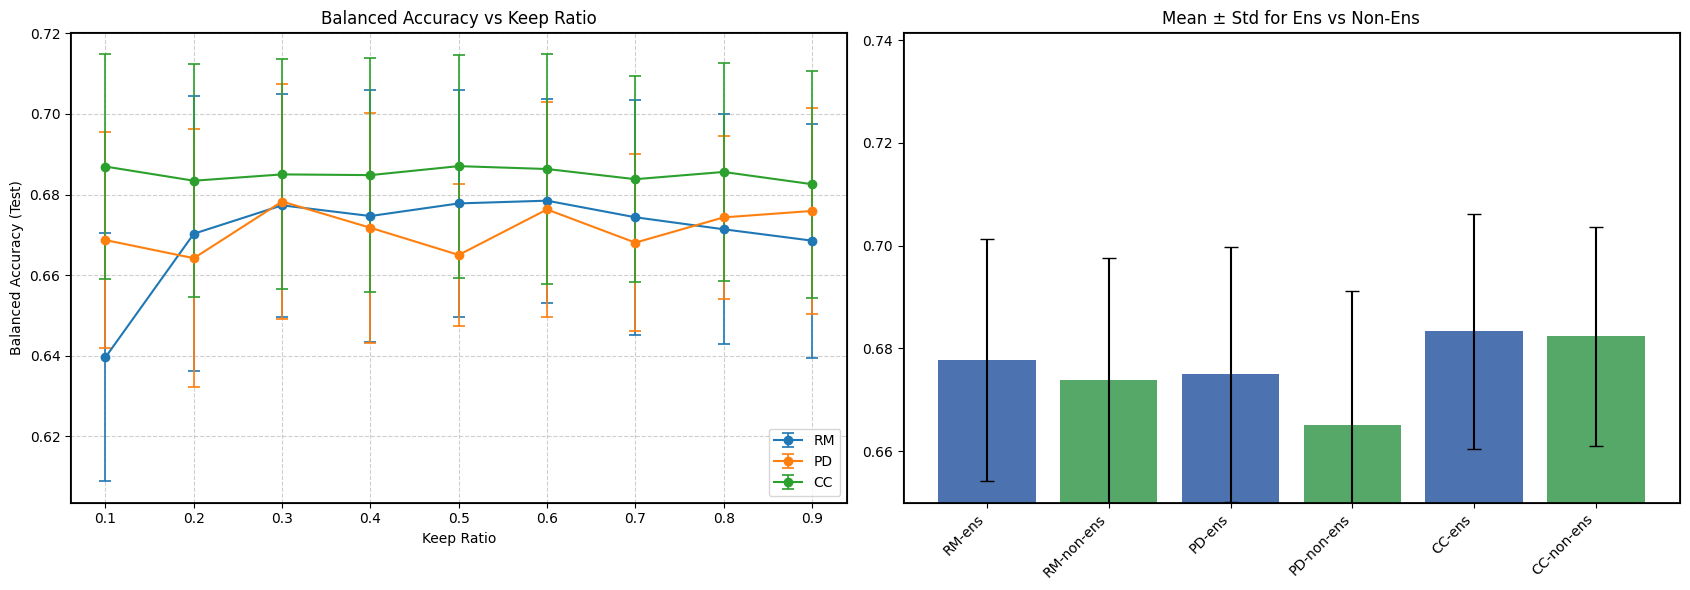

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(17,6))

# --- Subplot 1: line chart ---
ax = axes[0]
ratios = np.arange(0.1, 1.0, 0.1)
for method, values in tracks.items():
    means = [m for m, s in values]
    stds = [s for m, s in values]
    ax.errorbar(ratios, means, yerr=stds, label=method, capsize=4, 
                marker='o', linestyle='-', elinewidth=1.2, capthick=1.2)

ax.set_xlabel("Keep Ratio")
ax.set_ylabel("Balanced Accuracy (Test)")
ax.set_title("Balanced Accuracy vs Keep Ratio")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.6)
# border
x0, x1 = ax.get_xlim()
y0, y1 = ax.get_ylim()
rect = plt.Rectangle((x0, y0), x1-x0, y1-y0, linewidth=2, edgecolor="black", facecolor="none", zorder=10)
ax.add_patch(rect)

# --- Subplot 2: bar chart ---
ax2 = axes[1]
labels = []
means = []
stds = []
for method in ["RM","PD","CC"]:
    for g in ["ens","non-ens"]:
        labels.append(f"{method}-{g}")
        m, s = np.mean(bacc_tracks[method][g]), np.std(bacc_tracks[method][g])
        means.append(m)
        stds.append(s)

x = np.arange(len(labels))
ax2.bar(x, means, yerr=stds, capsize=5, color=["#4c72b0","#55a868"]*3)
ax2.set_xticks(x)
ax2.set_xticklabels(labels, rotation=45, ha="right")
# ax2.set_ylabel("Balanced Accuracy (Test)")
ax2.set_title("Mean ± Std for Ens vs Non-Ens")

# set ylim to start from 0.6
ax2.set_ylim(0.65, None)  # start from 0.6, auto-adjust upper limit

# border
x0, x1 = ax2.get_xlim()
y0, y1 = ax2.get_ylim()
rect2 = plt.Rectangle((x0, y0), x1-x0, y1-y0, linewidth=2, edgecolor="black", facecolor="none", zorder=10)
ax2.add_patch(rect2)

plt.tight_layout()
plt.show()